In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)


# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst Data Leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

df = df.sort_values("Datum").set_index("Datum")

#Target definieren
target_col = "Tagesumsatz Restaurant"

SARIMAX Model (with integrated Hyperparametertuning)

NaNs in ts: 0
NaNs in exog:
 weekday                                                  0
is_fr_sa                                                 0
Ferien-Value                                             0
Special-Day-Value                                        0
Niederschlag Tagessumme 6 UTC                            0
Sonnenscheindauer Tagessumme                             0
Lufttemperatur 2m Tagesmittel                            0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)    0
fourier_sin_1                                            0
fourier_cos_1                                            0
fourier_sin_2                                            0
fourier_cos_2                                            0
fourier_sin_3                                            0
fourier_cos_3                                            0
fourier_sin_4                                            0
fourier_cos_4                                            0
fourier_sin_5              

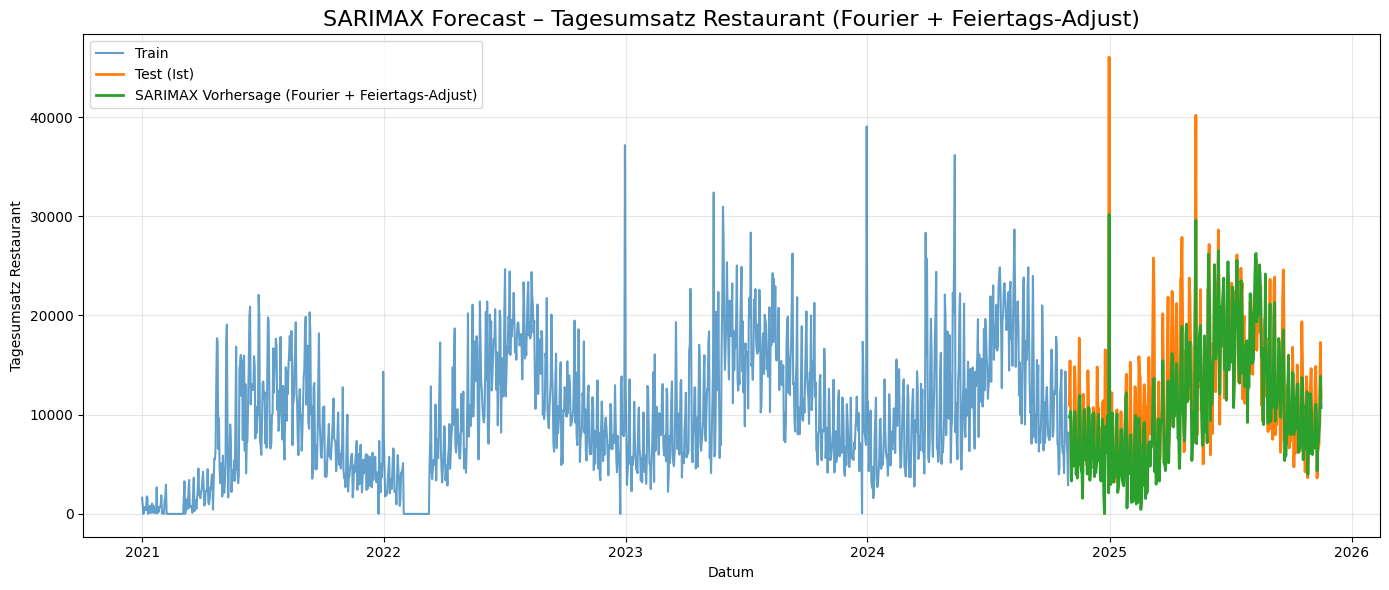

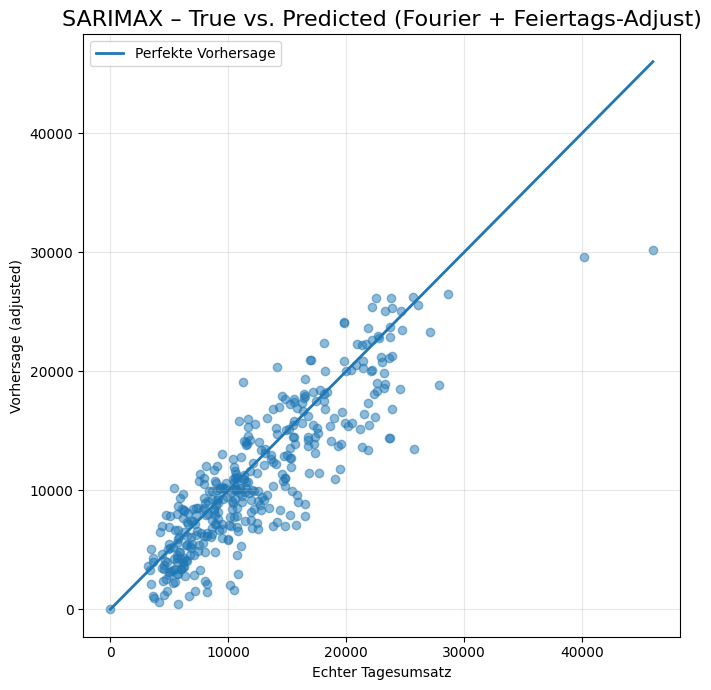


Weihnachten im Testset (24.12.):


,Datum,Ist,Vorhersage
53,2024-12-24,8.6,24.866667



Silvester im Testset (31.12.):


,Datum,Ist,Vorhersage
60,2024-12-31,46032.2,30177.766667



Muttertag im Testset:


,Datum,Ist,Vorhersage
191,2025-05-11,40176.1,29589.666667


In [17]:

# ==========================================
# 1) Zielzeitreihe (ts) vorbereiten
# ==========================================

ts = df[target_col].asfreq("D")
ts = pd.to_numeric(ts, errors="coerce")
ts = ts.ffill().bfill()

# ==========================================
# 2) Exogene Variablen (inkl. Fourier-Jahresseasonality)
# ==========================================

exog = pd.DataFrame(index=df.index)

# 2.1) Wochentag als Zahl (0=Mo,...,6=So)
if "Tag" in df.columns:
    mapping = {"Mo": 0, "Di": 1, "Mi": 2, "Do": 3, "Fr": 4, "Sa": 5, "So": 6}
    exog["weekday"] = df["Tag"].map(mapping)
else:
    exog["weekday"] = df.index.weekday  # Fallback

# 2.2) is_fr_sa übernehmen oder aus Datum bauen
if "is_fr_sa" in df.columns:
    exog["is_fr_sa"] = df["is_fr_sa"]
else:
    exog["is_fr_sa"] = ((df.index.weekday >= 5) | (df.index.weekday == 4)).astype(int)

# 2.3) Weitere numerische Features
feature_cols = [
    "Ferien-Value",
    "Special-Day-Value",
    "Niederschlag Tagessumme 6 UTC",
    "Sonnenscheindauer Tagessumme",
    "Lufttemperatur 2m Tagesmittel",
    "Durchschnittliche Anzahl Geburtstage (über 100 Jahre)"
]

for col in feature_cols:
    if col in df.columns:
        exog[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        exog[col] = 0.0  # falls Spalte fehlt

# 2.4) Yearly Fourier-Seasonality (Period ~ 365 Tage)
def make_fourier_features(index, period=365.25, K=5):
    """
    Erzeugt Fourier-Features für eine gegebene Periode.
    K = Anzahl der Harmonischen (je höher, desto flexibler die Jahreskurve).
    """
    df_fourier = pd.DataFrame(index=index)
    t = index.dayofyear.values.astype(float)

    for k in range(1, K + 1):
        df_fourier[f"fourier_sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        df_fourier[f"fourier_cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return df_fourier

fourier_df = make_fourier_features(exog.index, period=365.25, K=16)
exog = pd.concat([exog, fourier_df], axis=1)

# Exog säubern
exog = exog.asfreq("D")
exog = exog.replace([np.inf, -np.inf], np.nan)
exog = exog.ffill().bfill()

print("NaNs in ts:", ts.isna().sum())
print("NaNs in exog:\n", exog.isna().sum())

# ==========================================
# 3) Train / Test Split
# ==========================================

split_date = pd.Timestamp("2024-11-01")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

exog_train = exog.loc[train.index]
exog_test  = exog.loc[test.index]

print("Train length:", len(train))
print("Test length :", len(test))

assert not np.isnan(exog_train.values).any(), "exog_train hat noch NaNs!"
assert not np.isnan(exog_test.values).any(), "exog_test hat noch NaNs!"

# ==========================================
# 4) MAPE-Funktion
# ==========================================

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ==========================================
# 5) Grid-Search über (p,d,q) und wöchentliche Seasonality (P,D,Q,7)
#     Jahresseasonality kommt über Fourier, nicht über seasonal_order.
# ==========================================

from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.simplefilter("ignore", ConvergenceWarning)

candidate_orders = [
    (1, 0, 1),
    (2, 0, 1),
    (1, 1, 1)
]

candidate_seasonal_orders = [
    (1, 1, 1, 7),
    (2, 1, 1, 7),
    (1, 1, 2, 7)
]

results = []

for order in candidate_orders:
    for seasonal_order in candidate_seasonal_orders:
        try:
            print(f"Versuche order={order}, seasonal_order={seasonal_order} ...")
            model = SARIMAX(
                train,
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=True,
                enforce_invertibility=True
            )
            model_fit = model.fit(disp=False)

            forecast_res = model_fit.get_forecast(steps=len(test), exog=exog_test)
            forecast_tmp = forecast_res.predicted_mean

            mse_tmp  = mean_squared_error(test, forecast_tmp)
            rmse_tmp = mse_tmp ** 0.5
            mae_tmp  = mean_absolute_error(test, forecast_tmp)
            mape_tmp = mape(test, forecast_tmp)
            aic_tmp  = model_fit.aic

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": aic_tmp,
                "MSE": mse_tmp,
                "RMSE": rmse_tmp,
                "MAE": mae_tmp,
                "MAPE": mape_tmp
            })

        except Exception as e:
            print(f"Fehler bei order={order}, seasonal_order={seasonal_order}: {e}")
            continue

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="MAPE")
print("\n=== Grid-Search Ergebnisse (Top 5 nach MAPE) ===")
print(results_df.head())

best = results_df.iloc[0]
best_order = tuple(best["order"])
best_seasonal_order = tuple(best["seasonal_order"])
print(f"\nBestes Modell nach MAPE: order={best_order}, seasonal_order={best_seasonal_order}")
print(f"MAPE: {best['MAPE']:.2f}%, AIC: {best['AIC']:.2f}")

# ==========================================
# 6) Finales SARIMAX-Modell mit besten Parametern
# ==========================================

final_model = SARIMAX(
    train,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=True
)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())

# Roh-Forecast (ohne Feiertags-Adjust)
forecast_res = final_fit.get_forecast(steps=len(test), exog=exog_test)
forecast = forecast_res.predicted_mean  # Series mit DatetimeIndex = test.index

# ==========================================
# 7) Feiertags-Adjust (Weihnachten, Silvester, Muttertag)
# ==========================================

forecast_adjusted = forecast.copy()
test_dates = forecast_adjusted.index

df_full = df.copy()
df_full = df_full.reset_index().rename(columns={"index": "Datum"})

# df_full muss eine Datum-Spalte haben
if "Datum" not in df_full.columns:
    df_full = df_full.rename_axis("Datum").reset_index()

for d in test_dates:
    year = d.year

    # Weihnachten (24.12.)
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target_col
        )
        if avg_xmas is not None:
            forecast_adjusted.loc[d] = avg_xmas

    # Silvester (31.12.)
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target_col
        )
        if avg_silvester is not None:
            forecast_adjusted.loc[d] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df_full,
            date_func=mothers_day,
            year=year,
            target_col=target_col
        )
        if avg_mothers is not None:
            forecast_adjusted.loc[d] = avg_mothers

# ==========================================
# 8) Endgültige METRIKEN (mit Feiertagsanpassung)
# ==========================================

mse  = mean_squared_error(test, forecast_adjusted)
rmse = mse ** 0.5
r2   = r2_score(test, forecast_adjusted)
mae  = mean_absolute_error(test, forecast_adjusted)
mape_value = mape(test, forecast_adjusted)

y_naive = test.shift(1).bfill()
mse_naive = mean_squared_error(test, y_naive)
relative_MSE = mse / mse_naive

print("\n--- METRIKEN (SARIMAX mit Fourier + Feiertags-Adjust) ---")
print(f"Order         : {best_order}")
print(f"Seasonal order: {best_seasonal_order}")
print(f"MSE           : {mse:.2f}")
print(f"RMSE          : {rmse:.2f}")
print(f"R²            : {r2:.4f}")
print(f"MAE           : {mae:.2f}")
print(f"MAPE          : {mape_value:.2f}%")
print(f"Naive MSE     : {mse_naive:.2f}")
print(f"Relative MSE  : {relative_MSE:.4f}  ( <1 = besser als naive )")

# ==========================================
# 9) Plots
# ==========================================

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (Ist)", linewidth=2)
plt.plot(test.index, forecast_adjusted, label="SARIMAX Vorhersage (Fourier + Feiertags-Adjust)", linewidth=2)

plt.title("SARIMAX Forecast – Tagesumsatz Restaurant (Fourier + Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter: True vs. Predicted (adjusted)
plt.figure(figsize=(7,7))
plt.scatter(test.values, forecast_adjusted.values, alpha=0.5)

min_val = min(test.min(), forecast_adjusted.min())
max_val = max(test.max(), forecast_adjusted.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("SARIMAX – True vs. Predicted (Fourier + Feiertags-Adjust)", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("Vorhersage (adjusted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Übersicht über die Spezialtage im Test
results_sarimax = pd.DataFrame({
    "Datum": test.index,
    "Ist": test.values,
    "Vorhersage": forecast_adjusted.values
})

print("\nWeihnachten im Testset (24.12.):")
display(results_sarimax[
    (results_sarimax["Datum"].dt.month == 12) &
    (results_sarimax["Datum"].dt.day == 24)
])

print("\nSilvester im Testset (31.12.):")
display(results_sarimax[
    (results_sarimax["Datum"].dt.month == 12) &
    (results_sarimax["Datum"].dt.day == 31)
])

print("\nMuttertag im Testset:")
results_mothers = results_sarimax[
    results_sarimax["Datum"].apply(lambda d: d == mothers_day(d.year))
]
display(results_mothers)
